In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ДЗ 2. Наложение и удаление шума

Зашумить изображение при помощи шума гаусса, постоянного шума.
Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр,
фильтр нелокальных средних с различными параметрами.
Выяснить, какой фильтр показал лучший результат фильтрации шума.

## 1. Наложение шума

In [2]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
roi = (slice(300, 500), slice(450, 750))

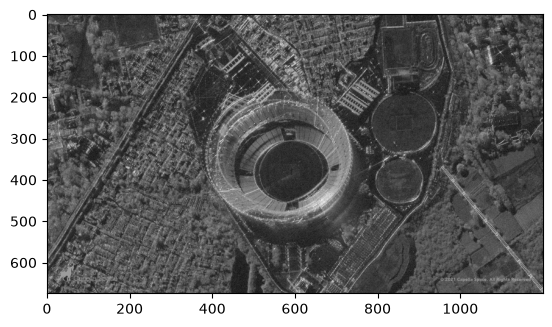

In [3]:
plt.imshow(image_gray, cmap="gray", vmin=0, vmax=255)

In [4]:
mean = 0
stddev = 50
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,   8,   0, ...,  55,   0,  40],
       [  1,  52,  34, ...,   0,  52,   0],
       [  0,   0,  26, ...,   0,   0,  73],
       ...,
       [  0,   0,  20, ..., 132,   0,   7],
       [  0,  17,   0, ...,   0,   3,  67],
       [ 80, 102,   0, ...,  11,   0,  54]],
      shape=(675, 1200), dtype=uint8)

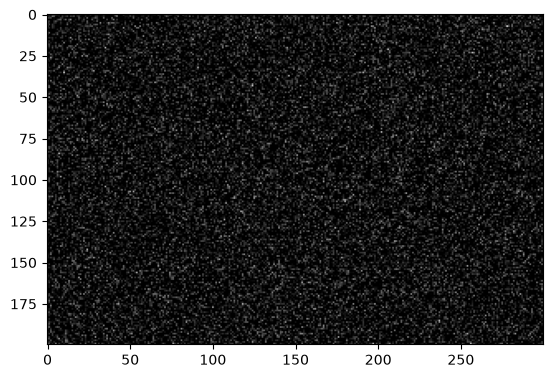

In [5]:
plt.imshow(noise_gauss[roi], cmap="gray", vmin=0, vmax=255)

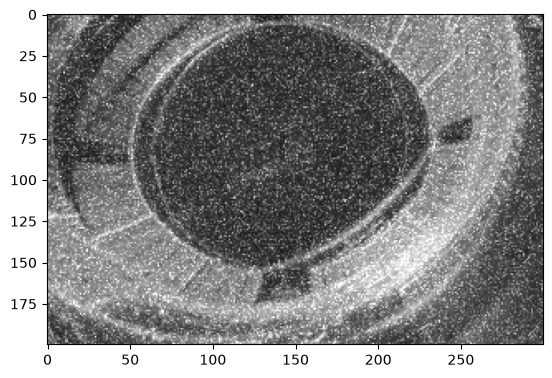

In [6]:
plt.imshow(cv2.add(image_gray, noise_gauss)[roi], cmap="gray", vmin=0, vmax=255)

In [7]:
image_noise_gauss = cv2.add(image_gray, noise_gauss)

In [8]:
def show_with_hist(images, titles, log_hist=()):
    n = len(images)
    fig, ax = plt.subplots(n, 2, figsize=(14, 4.5 * n))

    for i, (img, title) in enumerate(zip(images, titles)):
        ax[i, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
        ax[i, 0].set_title(title)
        ax[i, 0].axis('off')

        h = cv2.calcHist([img], [0], None, [256], (0, 256))
        ax[i, 1].plot(h)
        ax[i, 1].set_xlim(0, 255)
        ax[i, 1].grid()
        ax[i, 1].set_title(f"histogram: {title}")
        if i in log_hist:
            ax[i, 1].set_yscale('log')

    plt.tight_layout()
    plt.show()

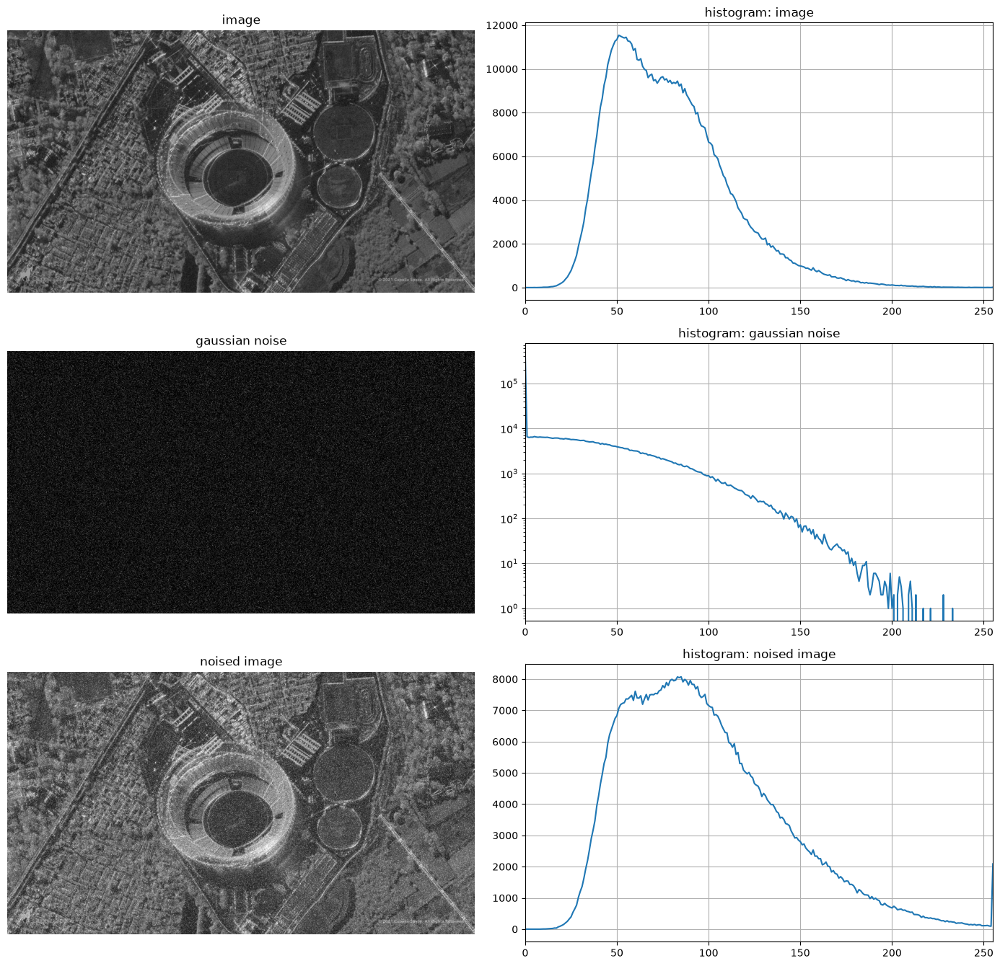

In [9]:
show_with_hist([image_gray, noise_gauss, image_noise_gauss],
                 ["image", "gaussian noise", "noised image"],
                 log_hist=(1,))

In [10]:
b = int(round(stddev * np.sqrt(1.5)))
noise_uniform = np.zeros(image_gray.shape, np.uint8)
cv2.randu(noise_uniform, 0, b)

array([[25, 53, 51, ..., 11, 43, 38],
       [17, 12, 35, ..., 51, 20, 51],
       [24, 39, 33, ..., 17, 32, 27],
       ...,
       [44, 15, 20, ..., 60, 11, 10],
       [49,  3,  9, ..., 35, 15, 18],
       [34, 48, 30, ..., 17, 58, 54]], shape=(675, 1200), dtype=uint8)

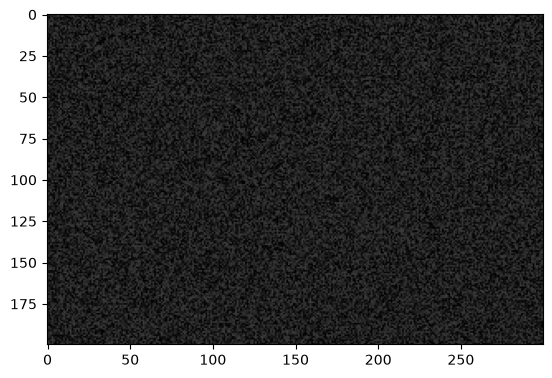

In [11]:
plt.imshow(noise_uniform[roi], cmap="gray", vmin=0, vmax=255)

In [12]:
image_noise_uniform = cv2.add(image_gray, noise_uniform)

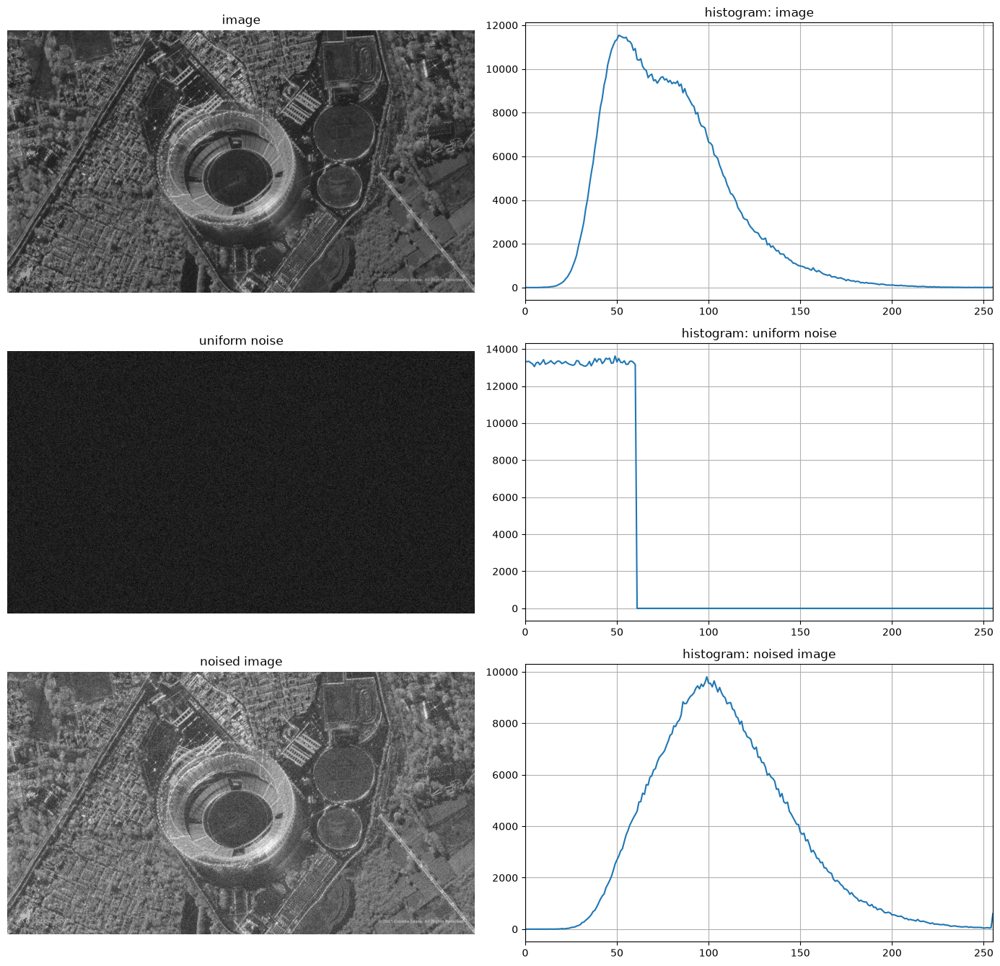

In [13]:
show_with_hist([image_gray, noise_uniform, image_noise_uniform],
                 ["image", "uniform noise", "noised image"])

In [14]:
from skimage.metrics import structural_similarity, mean_squared_error

In [15]:
def metrics(reference, image):
    mse = mean_squared_error(reference, image)
    ssim = structural_similarity(reference, image)
    return mse, ssim

In [16]:
results = []
mse, ssim = metrics(image_gray, image_noise_gauss)
results.append({"noise": "gauss", "filter": "none", "params": "-", "mse": mse, "ssim": ssim})
mse, ssim = metrics(image_gray, image_noise_uniform)
results.append({"noise": "uniform", "filter": "none", "params": "-", "mse": mse, "ssim": ssim})

In [17]:
for r in results:
    print(r["noise"], "MSE = %.1f" % r["mse"], "SSIM = %.3f" % r["ssim"])

gauss MSE = 1239.2 SSIM = 0.410
uniform MSE = 1211.5 SSIM = 0.588


## 2. Тестирование фильтров

In [18]:
def show_filter_roi(noises, variants, apply_filter, label):
    n = len(variants) + 1
    fig, ax = plt.subplots(n, len(noises), figsize=(6 * len(noises), 4 * n))

    for i, (noise_name, noisy) in enumerate(noises):
        mse, ssim = metrics(image_gray, noisy)
        ax[0, i].imshow(noisy[roi], cmap='gray', vmin=0, vmax=255)
        ax[0, i].set_title(f"{noise_name}, no filter\nMSE={mse:.0f}  SSIM={ssim:.3f}")

        for j, v in enumerate(variants, start=1):
            filtered = apply_filter(noisy, v)
            mse, ssim = metrics(image_gray, filtered)
            ax[j, i].imshow(filtered[roi], cmap='gray', vmin=0, vmax=255)
            ax[j, i].set_title(f"{label(v)}\nMSE={mse:.0f}  SSIM={ssim:.3f}")

    for a in ax.ravel():
        a.axis('off')
    plt.tight_layout()
    plt.show()

In [19]:
noises = [("gauss", image_noise_gauss), ("uniform", image_noise_uniform)]
ksizes = (3, 5, 7)

for noise_name, noisy in noises:
    for k in ksizes:
        filtered = cv2.medianBlur(noisy, k)
        mse, ssim = metrics(image_gray, filtered)
        results.append({"noise": noise_name, "filter": "median",
                        "params": f"ksize={k}", "mse": mse, "ssim": ssim})

In [20]:
for r in results:
    if r["filter"] == "median":
        print(f'{r["noise"]:8} {r["params"]:10} MSE = {r["mse"]:7.1f}  SSIM = {r["ssim"]:.3f}')

gauss    ksize=3    MSE =   376.5  SSIM = 0.636
gauss    ksize=5    MSE =   378.7  SSIM = 0.569
gauss    ksize=7    MSE =   424.6  SSIM = 0.486
uniform  ksize=3    MSE =  1062.1  SSIM = 0.638
uniform  ksize=5    MSE =  1097.2  SSIM = 0.541
uniform  ksize=7    MSE =  1136.2  SSIM = 0.458


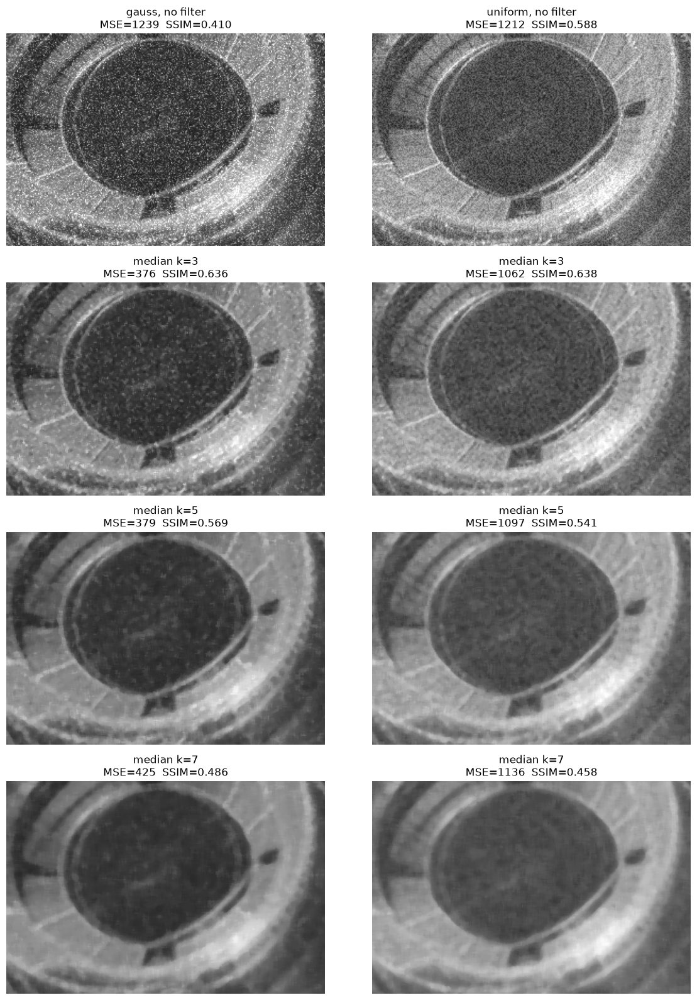

In [21]:
show_filter_roi(noises, ksizes,
                lambda im, k: cv2.medianBlur(im, k),
                lambda k: f"median k={k}")

In [22]:
noises = [("gauss", image_noise_gauss), ("uniform", image_noise_uniform)]
ksizes = (3, 5, 7)
sigmas = (1, 3, 10)

for i, (noise_name, noisy) in enumerate(noises):
    for j, k in enumerate(ksizes, start=1):
        filtered = cv2.GaussianBlur(noisy, (k, k), 0)
        mse, ssim = metrics(image_gray, filtered)
        results.append({"noise": noise_name, "filter": "gaussian",
                        "params": f"ksize={k} sigma=0", "mse": mse, "ssim": ssim})

for i, (noise_name, noisy) in enumerate(noises):
    for j, sigma in enumerate(sigmas, start=1):
        filtered = cv2.GaussianBlur(noisy, (7, 7), sigma)
        mse, ssim = metrics(image_gray, filtered)
        results.append({"noise": noise_name, "filter": "gaussian",
                        "params": f"ksize=7 sigma={sigma}", "mse": mse, "ssim": ssim})

In [23]:
for r in results:
      if r["filter"] == "gaussian":
          print(f'{r["noise"]:8} {r["params"]:18} MSE = {r["mse"]:7.1f}  SSIM = {r["ssim"]:.3f}')

gauss    ksize=3 sigma=0    MSE =   580.4  SSIM = 0.666
gauss    ksize=5 sigma=0    MSE =   570.4  SSIM = 0.662
gauss    ksize=7 sigma=0    MSE =   594.4  SSIM = 0.616
uniform  ksize=3 sigma=0    MSE =  1010.7  SSIM = 0.744
uniform  ksize=5 sigma=0    MSE =  1035.1  SSIM = 0.701
uniform  ksize=7 sigma=0    MSE =  1077.5  SSIM = 0.628
gauss    ksize=7 sigma=1    MSE =   567.9  SSIM = 0.667
gauss    ksize=7 sigma=3    MSE =   654.8  SSIM = 0.510
gauss    ksize=7 sigma=10   MSE =   678.2  SSIM = 0.471
uniform  ksize=7 sigma=1    MSE =  1030.0  SSIM = 0.710
uniform  ksize=7 sigma=3    MSE =  1147.9  SSIM = 0.507
uniform  ksize=7 sigma=10   MSE =  1172.1  SSIM = 0.467


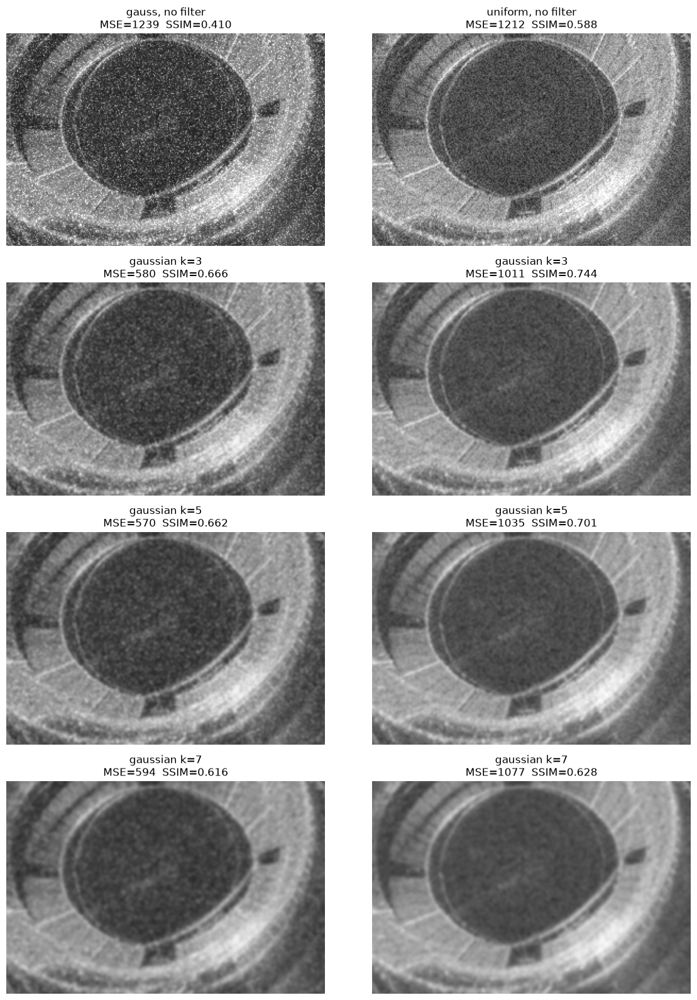

In [24]:
show_filter_roi(noises, ksizes,
                lambda im, k: cv2.GaussianBlur(im, (k, k), 0),
                lambda k: f"gaussian k={k}")

In [25]:
noises = [("gauss", image_noise_gauss), ("uniform", image_noise_uniform)]
bilat_params = [(9, 75, 75), (9, 150, 150), (15, 75, 75), (9, 25, 75)]

for noise_name, noisy in noises:
    for d, s_color, s_space in bilat_params:
        filtered = cv2.bilateralFilter(noisy, d, s_color, s_space)
        mse, ssim = metrics(image_gray, filtered)
        results.append({"noise": noise_name, "filter": "bilateral",
                        "params": f"d={d} sColor={s_color} sSpace={s_space}",
                        "mse": mse, "ssim": ssim})

In [26]:
for r in results:
    if r["filter"] == "bilateral":
        print(f'{r["noise"]:8} {r["params"]:30} MSE = {r["mse"]:7.1f}  SSIM = {r["ssim"]:.3f}')

gauss    d=9 sColor=75 sSpace=75        MSE =   535.2  SSIM = 0.582
gauss    d=9 sColor=150 sSpace=150      MSE =   620.1  SSIM = 0.515
gauss    d=15 sColor=75 sSpace=75       MSE =   590.6  SSIM = 0.502
gauss    d=9 sColor=25 sSpace=75        MSE =   870.0  SSIM = 0.453
uniform  d=9 sColor=75 sSpace=75        MSE =  1089.1  SSIM = 0.567
uniform  d=9 sColor=150 sSpace=150      MSE =  1148.4  SSIM = 0.493
uniform  d=15 sColor=75 sSpace=75       MSE =  1156.9  SSIM = 0.467
uniform  d=9 sColor=25 sSpace=75        MSE =  1027.1  SSIM = 0.697


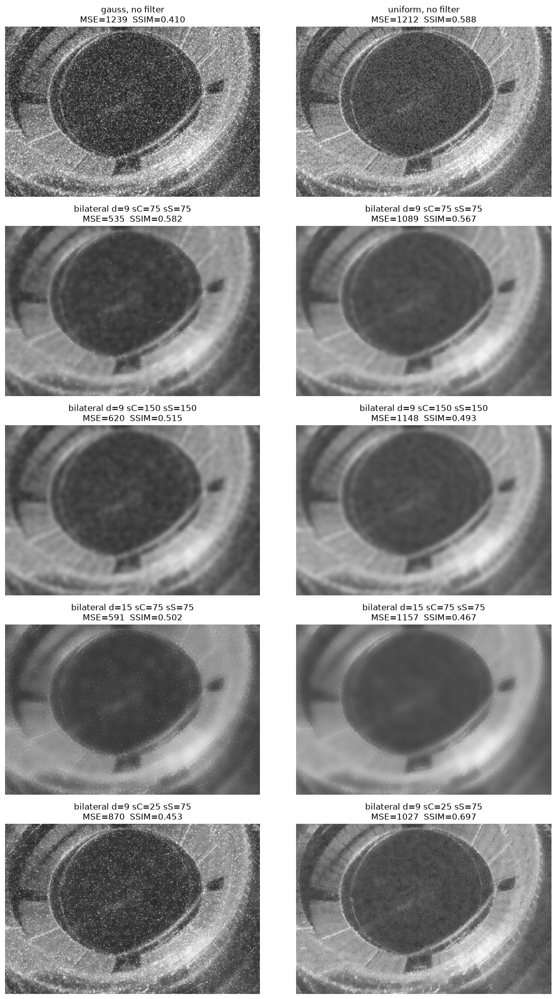

In [27]:
show_filter_roi(noises, bilat_params,
                lambda im, p: cv2.bilateralFilter(im, *p),
                lambda p: f"bilateral d={p[0]} sC={p[1]} sS={p[2]}")

In [28]:
h_values = (10, 20, 30, 40)

for noise_name, noisy in noises:
    for h in h_values:
        filtered = cv2.fastNlMeansDenoising(noisy, None, h, 7, 21)
        mse, ssim = metrics(image_gray, filtered)
        results.append({"noise": noise_name, "filter": "nlm",
                        "params": f"h={h}", "mse": mse, "ssim": ssim})

In [29]:
for r in results:
    if r["filter"] == "nlm":
        print(f'{r["noise"]:8} {r["params"]:10} MSE = {r["mse"]:7.1f}  SSIM = {r["ssim"]:.3f}')

gauss    h=10       MSE =  1239.2  SSIM = 0.410
gauss    h=20       MSE =   701.9  SSIM = 0.573
gauss    h=30       MSE =   601.8  SSIM = 0.509
gauss    h=40       MSE =   680.9  SSIM = 0.417
uniform  h=10       MSE =  1186.1  SSIM = 0.604
uniform  h=20       MSE =  1026.5  SSIM = 0.602
uniform  h=30       MSE =  1117.9  SSIM = 0.456
uniform  h=40       MSE =  1186.7  SSIM = 0.386


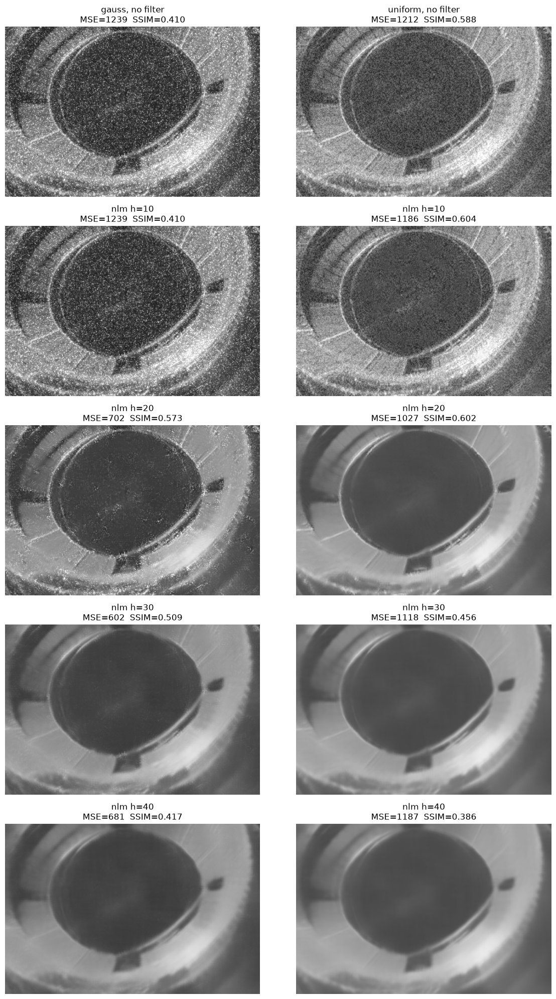

In [30]:
show_filter_roi(noises, h_values,
                lambda im, h: cv2.fastNlMeansDenoising(im, None, h, 7, 21),
                lambda h: f"nlm h={h}")

## 3. Сводная таблица

In [31]:
import pandas as pd

df = pd.DataFrame(results)

base = df[df['filter'] == 'none'].set_index('noise')

df['mse_gain']  = df.apply(
    lambda r: (base.loc[r['noise'], 'mse'] - r['mse']) / base.loc[r['noise'], 'mse'], axis=1)
df['ssim_gain'] = df.apply(
    lambda r: (r['ssim'] - base.loc[r['noise'], 'ssim']) / base.loc[r['noise'], 'ssim'], axis=1)
df['score'] = df['mse_gain'] + df['ssim_gain']

In [32]:
def highlight_best(data):
    styles = pd.DataFrame('', index=data.index, columns=data.columns)
    styles.loc[data['filter'] == 'none', :] = 'background-color: #fff3b0'
    for noise, grp in data.groupby('noise'):
        styles.loc[grp['mse'].idxmin(),  'mse']  = 'background-color: lightgreen'
        styles.loc[grp['ssim'].idxmax(), 'ssim'] = 'background-color: lightgreen'
    return styles

cols = ['noise', 'filter', 'params', 'mse', 'ssim']

table = (df.sort_values(['noise', 'score'], ascending=[True, False])
             .reset_index(drop=True)[cols])

table.style.apply(highlight_best, axis=None) \
             .format({'mse': '{:.1f}', 'ssim': '{:.3f}'})

,noise,filter,params,mse,ssim
0,gauss,median,ksize=3,376.5,0.636
1,gauss,gaussian,ksize=7 sigma=1,567.9,0.667
2,gauss,gaussian,ksize=3 sigma=0,580.4,0.666
3,gauss,gaussian,ksize=5 sigma=0,570.4,0.662
4,gauss,median,ksize=5,378.7,0.569
5,gauss,gaussian,ksize=7 sigma=0,594.4,0.616
6,gauss,bilateral,d=9 sColor=75 sSpace=75,535.2,0.582
7,gauss,median,ksize=7,424.6,0.486
8,gauss,nlm,h=20,701.9,0.573
9,gauss,bilateral,d=9 sColor=150 sSpace=150,620.1,0.515


## Выводы

**Параметры эксперимента:** шум Гаусса (mean=0, stddev=50) и постоянный (равномерный) шум на отрезке [0, 61].
Диапазон постоянного шума подобран так, чтобы мощности шумов совпали: b = stddev * sqrt(1.5).
Проверка: MSE зашумлённых изображений 1239.2 и 1211.5.

**Лучшие результаты:**

| Шум | База (без фильтра) | Лучший MSE | Лучший SSIM |
|---|---|---|---|
| гауссов | MSE 1239.2 / SSIM 0.410 | медианный k=3 — 376.5 | гауссов k=7, sigma=1 — 0.667 |
| постоянный | MSE 1211.5 / SSIM 0.588 | NLM h=20 — 1026.5 | гауссов k=3 — 0.744 |

### 1. Почему на гауссовом шуме выиграл медианный фильтр

Из-за типа `uint8` отрицательная половина шума обрезалась в ноль: половина пикселей осталась нетронутой,
остальные получили крупные добавки. Получился шум типа «соль», а с ним медиана справляется лучше гауссиана —
при сортировке выброс уходит на край окна и не попадает в результат, а усреднение размазывает его по соседям.

### 2. Почему билатеральный и NLM работают на постоянном шуме

В постоянном шуме добавки от 0 до 61 равновероятны, поэтому соседние пиксели расходятся максимум на 61 уровень.
В гауссовом разница доходит до 233. Билатеральный и NLM отличают деталь от шума по перепаду яркости:
небольшие перепады они сглаживают, большие считают границами объектов и сохраняют.
Поэтому на постоянном шуме они работают, а на гауссовом сохраняют выбросы вместо того, чтобы их убрать.

### 3. Почему окно 3x3 лучше 7x7

При большом окне убирается больше шума, но вместе с ним стираются детали. Поэтому у размера окна есть оптимум —
в этом эксперименте это 3x3. На постоянном шуме окна 5x5 и 7x7 уронили SSIM до 0.541 и 0.458 против базовых 0.588,
то есть сделали хуже, чем если бы фильтрации не было вообще.

### 4. Что означает строка nlm h=10 с метриками, равными базовым

h — порог похожести блоков. NLM усредняет пиксель с теми соседями, у которых похожа вся окрестность;
при малом h ни один блок не проходит порог, все веса обнуляются, и у пикселя остаётся только он сам.
При h=10 метрики совпали с базовыми (MSE 1239.2 и SSIM 0.410) — фильтр не изменил изображение вообще.
Значит h нужно согласовывать с уровнем шума: здесь фильтр заработал только начиная с h=20.

### 5. Почему MSE и SSIM выбрали разных победителей

Метрики меряют разное: MSE — разность яркостей пиксель к пикселю, SSIM — сохранность структуры.
Медианный фильтр убирает крупные выбросы целиком, поэтому сильно снижает MSE.
Гауссов выбросы не убирает, а размазывает по соседям — MSE у него выше, зато усредняет он плавно
и лучше сохраняет структуру, отсюда выше SSIM.
